In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

In [14]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [15]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized


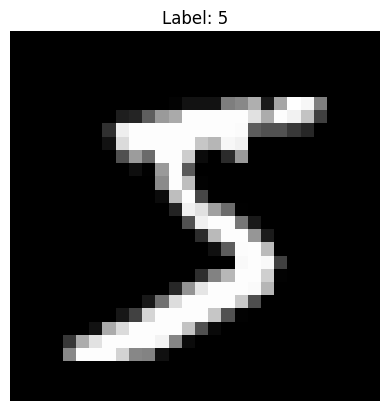

In [16]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy",
optimiser="adam")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]



# test show a digit
show_digit(X_train, y_train, 0)



Epoch 1/25 - Loss: 0.0084
Model improved!
Validation Loss: 0.1892 - Validation Accuracy: 94.51%
...
Epoch 2/25 - Loss: 0.0054
Model improved!
Validation Loss: 0.1687 - Validation Accuracy: 95.59%
...
Epoch 3/25 - Loss: 0.0046
Model improved!
Validation Loss: 0.1632 - Validation Accuracy: 95.44%
...
Epoch 4/25 - Loss: 0.0040
Model improved!
Validation Loss: 0.1374 - Validation Accuracy: 96.55%
...
Epoch 5/25 - Loss: 0.0038
Validation Loss: 0.1644 - Validation Accuracy: 95.93%
...
Epoch 6/25 - Loss: 0.0036
Validation Loss: 0.1753 - Validation Accuracy: 96.03%
...
Epoch 7/25 - Loss: 0.0033
Validation Loss: 0.1431 - Validation Accuracy: 96.81%
...
Epoch 8/25 - Loss: 0.0032
Validation Loss: 0.1527 - Validation Accuracy: 96.63%
...
Epoch 9/25 - Loss: 0.0031
Validation Loss: 0.1506 - Validation Accuracy: 96.64%
Early stopping executed


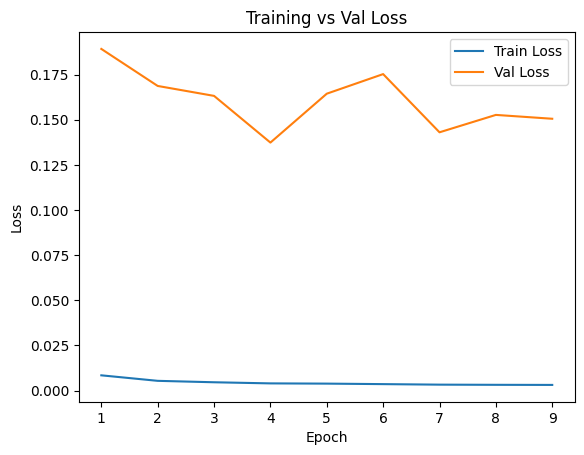

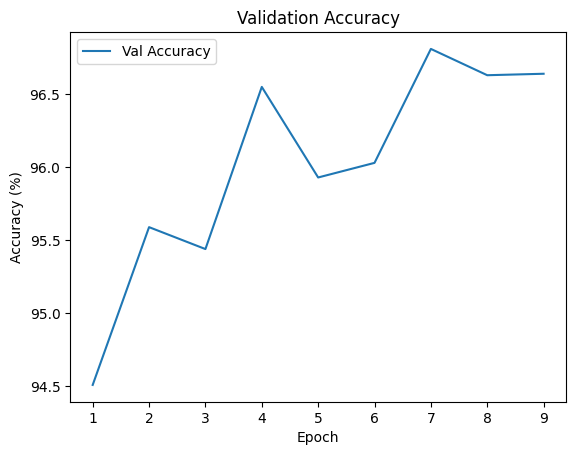

Test Accuracy: 96.26%


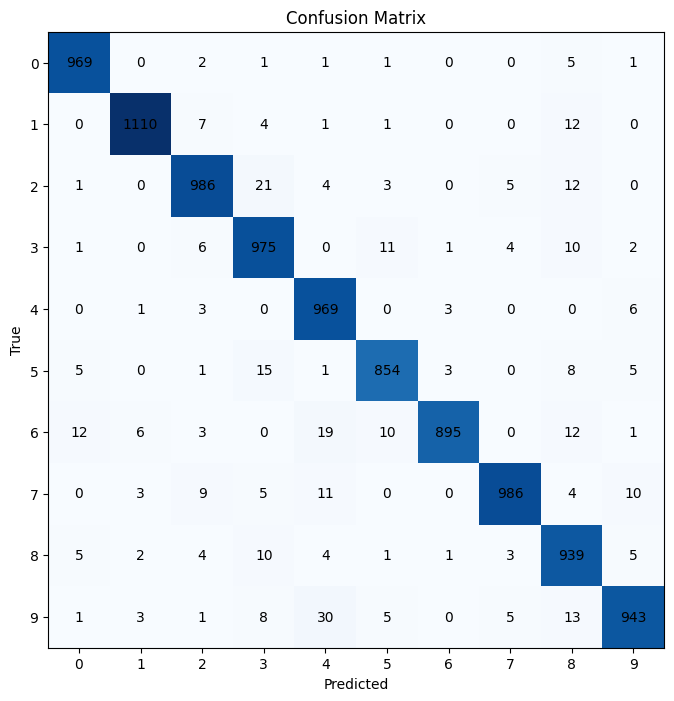

In [17]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=25, batch_size=32, patience=5)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

FCN initialized
Epoch 1/5 - Loss: 0.2377
...
Epoch 2/5 - Loss: 0.1096
...
Epoch 3/5 - Loss: 0.0757
...
Epoch 4/5 - Loss: 0.0574
...
Epoch 5/5 - Loss: 0.0454
...
Batch size 1: 97.51%
FCN initialized
Epoch 1/5 - Loss: 0.1174
...
Epoch 2/5 - Loss: 0.0558
...
Epoch 3/5 - Loss: 0.0464
...
Epoch 4/5 - Loss: 0.0418
...
Epoch 5/5 - Loss: 0.0388
...
Batch size 8: 92.35%
FCN initialized
Epoch 1/5 - Loss: 0.0659
...
Epoch 2/5 - Loss: 0.0542
...
Epoch 3/5 - Loss: 0.0448
...
Epoch 4/5 - Loss: 0.0376
...
Epoch 5/5 - Loss: 0.0323
...
Batch size 32: 82.57%
FCN initialized
Epoch 1/5 - Loss: 0.0370
...
Epoch 2/5 - Loss: 0.0349
...
Epoch 3/5 - Loss: 0.0332
...
Epoch 4/5 - Loss: 0.0316
...
Epoch 5/5 - Loss: 0.0301
...
Batch size 64: 53.50%
FCN initialized
Epoch 1/5 - Loss: 0.0182
...
Epoch 2/5 - Loss: 0.0179
...
Epoch 3/5 - Loss: 0.0176
...
Epoch 4/5 - Loss: 0.0174
...
Epoch 5/5 - Loss: 0.0172
...
Batch size 128: 25.82%
FCN initialized
Epoch 1/5 - Loss: 0.0098
...
Epoch 2/5 - Loss: 0.0097
...
Epoch 3/5 - 

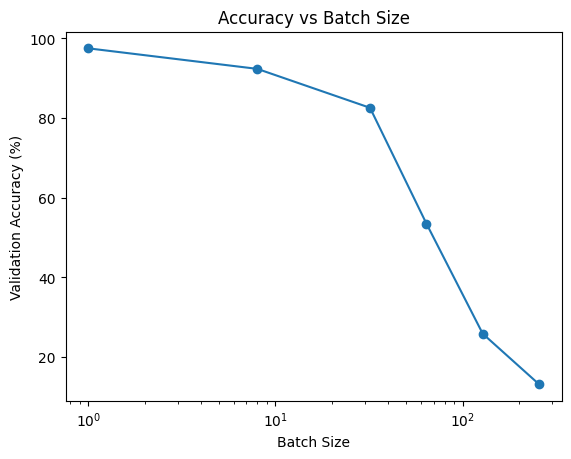

In [18]:
# testing batch_size
batch_sizes = [1, 8, 32, 64, 128, 256]
results = {}

for bs in batch_sizes:
    model = FCN([
        Layer(784),
        Layer(128, 'relu'),
        Layer(10, 'softmax')
    ], loss='cross_entropy', learning_rate=0.01)
    
    model.train(X_train, y_train, epochs=5, batch_size=bs)
    acc = accuracy(model, X_val, y_val)
    results[bs] = acc
    print(f"Batch size {bs}: {acc:.2f}%")

# plot
print("Batch sizes:", batch_sizes)
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Batch Size')
plt.show()

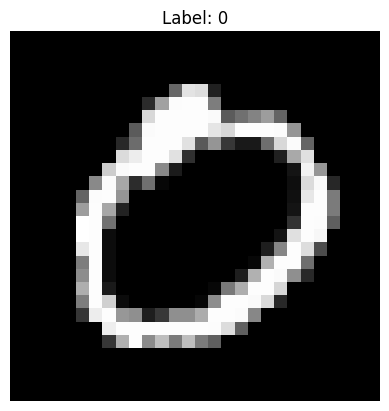

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Prediction: 0


In [19]:
import random

index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))